OPERAZIONI MORFOLOGICHE: GEOMETRICA DEL SEGNALE BINARIO

Le operazioni morfologiche non lavorano sui valori numerici dei pixel, come blur e filtri, ma sulla forma degli oggetti presenti nell'immagine.

Si intende modifica della geometrica di regioni bianche o nere

- Erosione e Dilatazione
- Opening e Closing
- Esrazione di scheletri, ridurre un oggetto complesso alla sua essenza.

Cosa significa manipolare la forma matematicamente
Immagina di avere uno stampino per biscotti, questo stampino scorre sull'immagine e decide cosa deve sopravvivere e cosa deve sparire.

Le operazioni morfologiche rispondono a domande del tipo:
- posso ingrandire questo oggetto?
- posso restringerlo?
- posso eliminare piccoli buchi?
- posso chiudere piccoli buchi?
- posso separare due oggetti quasi attaccati?
Ed è qui che entrano in gioco erosione, dilatazione, apertura e chiusura.
Il concetto fondamentale è lo structuring element, cioè l'elemento strutturante.
E' una piccola matrice, simile al kernel visto nei filtri
Esempio
111
111
111
Un kernel 3x3
Questo elemento viene fatto scorrere sopra l'immagine. Ma, diversamente da un Gaussian Blur, non calcola la media. Controlla la presenza o assenza dei pixel dell'oggetto.

# EROSIONE *
La prima operazione fondamentale è EROSIONE
L'erosione restringe le zone bianche
eroded=cv2.erode(binary_image,kernel,iterations=1)
E' come un cubetto di ghiaccio che si scioglie. Consuma i bordi dall'esterno verso l'interno, il pixel sopravvive solo se tutti i suoi vicini sono bianchi. E lo strumento perfetto per staccare due oggetit che si toccano appena

Supponiamo di partire da
00000
01110
01110
01110
00000
Dopo l'erosione 3x3, concetttualmente postesti avere:
00000
00000
00100
00000
00000
Il pixel rimane bianco (1) solamente quando l'elemeto strutturante (matrice 3x3) 'entra completamente' nell'oggetto
Quindi i pixel sui bordi vengono eliminati.
Uso pratico: eliminare piccoli punti bianchi
Un pixel isolato viene rimosso, potrebbe anche essere rumore.
Il problema è che contemporaneamente restringi anche l'oggetto vero.

* DILATAZIONE *
La seconda operazione è la DILATAZIONE
Fa esattamente l'opposto delll0erosione, espande le zone biache.
E' come una goccia d'olio che si espande sul foglio.
Se il kernel tocca anche un solo pixel bianco, trasforma tutto in bianco. Il risultato è l'insieme di tutti i punti dove lo stapino tocca l'oggetto
Usato per crepe e le dilatazioni 
Se hai:
00000
00000
00100
00000
00000
dopo la dilatazione puoi ottenere:
00000
01110
01110
01110
00000

- L'elemento strutturale è una piccola matrice che definisce il vicinato e la natura dell'operazione spaziale.
- L'Erosione consuma i bordi dell'oggetto: un pixel diventa bianco solo se tutti i pixel sotto l'elemento strutturante sono bianchi
- La Dilazione espande i confini: un pixel diventa bianco se almeno un pixel sotto l'elemento strutturante è bianco
- L'Erosione è utile per staccare oggetti uniti, mentre la dilatazione è perfetta per fondere segmenti vicini ma separati.

Implementazione con Opern CV
In opern CV tutto parte dalla creazione del kernel

cv2.getStructuringElement
Funzione necessaria per creare kernel di diverse forme come rettangoli, croci o ellissi, influenzando la direizion della modifica. Possiamo scegliere la forma del kernel, una croce per analizzare le linee un ellissi per una forma organica o un rettangolo per documenti
cv2.erode
Riduce la dimensione degli oggetti binari. Utile per eliminare piccoli punti isolati di rumore chiamati 'white noise'
cv2.dilate
Accresce la massa degli oggetti. Viene spesso usata dopo l'edge detection per ispessire i contorni rilevanti e renderli continui

L'erosione è fantastica il cosidetto white noise (puntini bianchi che sporcano sfondo nero)
la dilatazioneè utile dopo aver rilevato i bordi cno cannny per renderli più spessi e facili da individuare.

Ma c'è un'operazione matematica che lega queste due operazioni

Proprietà di Dualità
ci dice che erodere un oggetto bianco su sfondo nero, è la stessa cosa che dilatare su sfondo nero.

Ma cosa succede se vogliamo pulire l'immagine senza che l'oggetto diventi troppo piccolo o troppo grande?

Qui entrnao in gico l'opening e il closing

Singolarmente l'erosione rimpicciolisce a la dilatazione ingrandisce.
Se le combiniamo otteniamo una pulizia selettiva.

* OPENING *
Cioè apertura
perchè prima restringi e poi riallarghi?
per eliminare piccoli oggetti senza modificarne troppo quelli grandi
E' come passare una carte vetro fine, toglie le scheggie esterne ma lascia la struttura.
Esempio
01000
00000
01110
01110
01110
l'erosioe elimina il puntino in alto solo
Poi la dilatazione riporta l'oggetto principale più o meno alla dimensione iniziale.
E' molto usato per rimuovere rumore dopo una segmentazione

L'opening è un'erosione seguita da una dilatazione. L'erosione rimuove picoli oggetti esterni senza alterare sensibilmente i grandi

* CLOSING *
cioè Chiusura
E' l'opposto
Serve principalmente a chiudere buchi e fessure.
Esempio
11111
11111
11011
11111
dopo il closing
11111
11111
11111
11111
con opening elimino il rumore esterno, con closing chiudo piccoli buchi interni

Il closing dilata per chiudere i buchi e dopo erode per trovare la taglia corretta.

C'è una proprietà chiamata idempotenza, garantisce che l'applicazione ripetuta di opening o closing non modifichi ulteriormente l'immagine dopo il primo passaggio.
Una volta che ho pulito un immagine con un opening, passarlo una seconda volta con lo stesso kernel, non cambia più nulla (idempotenza). Ma è un segnale che l'immagine è morfologicamente stabile.

Vediamo come OpenCV gestisce queste operazioni in modo efficiente.

- Morfologia integrata: invece di chiamare due funzioni, usiamo cv2.morphologyEx passando il flag cv2.PARPH_OPEN o cv2.MORPH_CLOSE 

Ma come scegliamo quando usare opening e closing?

Rimozione del rumore impulsivo
L'uso di opening o di closing, dipende dal tipo di sporco che dobbiamo gestire.
Se avete pixel bianchi su sfondo nero opening è la soluzione
se avete pixel neri su oggetto bianco la soluzione è closing
La regola è: la dimensione del kernel deve essere leggermente più grande dell'artefatto che si vuole eliminare.
Se il kernel è troppo grande, si rischia di distruggere anche le parti importanti dell'immagine.
E' un equilibrio sottile

Riduzione all'essenza
La Scheletrizzazione immagina di bruciare un foglio di carta sagomato partendo dai bordi, il punto in cui si incotrano le fiamme forma lo scheletro.
Perchè ci serve?
Pensa al riconoscimento alla scrittura manuale, non ci interessa quanto sono spessi i tratti, ci interessa come sono collegate le sue aste.
Riducendo tutto ad uno spessore di un singolo pixel rendiamo il lavoro di l ai molto più semplice e veloce.

Come otteniamo lo scheletro
Erodiamo l'immagine un po alla volta, ad ogni passo salviamo ciù che sta per sparire ma è essenziale per la struttura.
Il processo di ferma quando non c'è più nulla da erodere.

Come si sposa tutto questo con il deeoplearning

La morfologia è un potenziatore per le reti neurali.

es .Dilatazoine per rendere le scritte più spesse

Ma attenzione a non confodere scheletro ed assotigliamento.


32964/32964 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


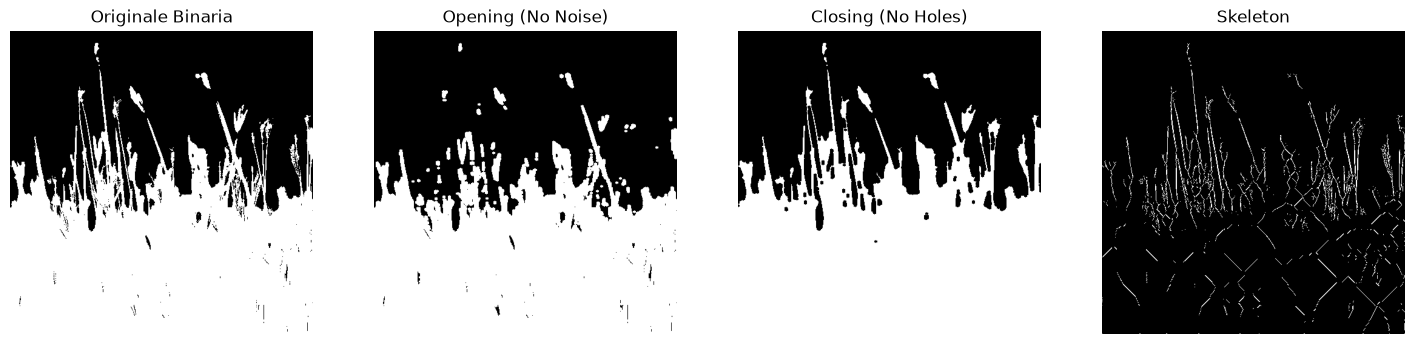

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 1.]], device='cuda:0')

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Best Practice 2026: Configurazione Keras 3 con backend PyTorch per interoperabilità
os.environ["KERAS_BACKEND"] = "torch"
import keras

def morphological_processing_lab(url=None):
    # 0. SCARICAMENTO AUTOMATICO (Novità)
    # Se non viene fornito un URL, usiamo un'immagine standard ideale per la morfologia
    # In questo caso, un'immagine con rumore perfetta per testare Opening e Closing.
    if url is None:
        url = "https://picsum.photos/500/500?grayscale"
    
    # keras.utils.get_file scarica il file e restituisce il percorso locale
    image_path = keras.utils.get_file("sample_morphology.png", url)

    # 1. CARICAMENTO E BINARIZZAZIONE
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Errore nel caricamento dell'immagine scaricata da: {url}")

    # Usiamo il Thresholding di Otsu per trovare automaticamente il punto di separazione ottimale.
    # Teoria: Otsu minimizza la varianza intra-classe dei pixel neri e bianchi.
    _, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 2. DEFINIZIONE DELL'ELEMENTO STRUTTURANTE (KERNEL)
    # Il kernel definisce la "forma" con cui analizziamo l'immagine.
    # Un kernel 5x5 ellittico è più "morbido" di uno rettangolare.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # 3. OPENING (Erosione -> Dilatazione)
    # Teoria: Rimuove piccoli artefatti bianchi esterni (rumore 'sale').
    # L'erosione elimina i punti piccoli, la dilatazione riporta gli oggetti grandi alla dimensione originale.
    opening = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel, iterations=1)

    # 4. CLOSING (Dilatazione -> Erosione)
    # Teoria: Chiude piccoli buchi neri interni agli oggetti (rumore 'pepe').
    # La dilatazione fonde i bordi vicini, l'erosione previene l'espansione eccessiva dell'oggetto.
    closing = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)

    # 5. SCHELETRIZZAZIONE (Algoritmo Iterativo)
    # Teoria: Consiste nel sottrarre ripetutamente l'apertura dell'immagine erosa.
    # È l'essenza topologica: riduce l'oggetto a linee spesse 1 pixel.
    skeleton = np.zeros(binary_img.shape, np.uint8)
    temp_img = binary_img.copy()
    
    # Elemento strutturante a croce (standard per scheletrizzazione)
    cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    while True:
        # Step: Erosione, Apertura, Sottrazione
        eroded = cv2.erode(temp_img, cross_kernel)
        temp_open = cv2.dilate(eroded, cross_kernel)
        subset = cv2.subtract(temp_img, temp_open)
        skeleton = cv2.bitwise_or(skeleton, subset)
        temp_img = eroded.copy()
        
        # Se non ci sono più pixel da erodere, abbiamo finito
        if cv2.countNonZero(temp_img) == 0:
            break

    # 6. INTEGRAZIONE KERAS 3 (Pre-processing per CNN)
    # Convertiamo lo scheletro in un tensore per usarlo come feature spaziale.
    # Normalizziamo a [0, 1] come richiesto dai modelli PyTorch.
    skeleton_tensor = keras.ops.convert_to_tensor(skeleton, dtype="float32") / 255.0

    # VISUALIZZAZIONE
    titles = ['Originale Binaria', 'Opening (No Noise)', 'Closing (No Holes)', 'Skeleton']
    images = [binary_img, opening, closing, skeleton]
    
    plt.figure(figsize=(18, 6))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

    return skeleton_tensor

morphological_processing_lab()